# E3 · Power costs and compute margins

**Optional decision:** Who bears electricity costs, and how much contribution remains when that bill rises? Read Notebooks 1 and 2 first; allow 10–15 minutes. Explicitly switch from a capacity reseller with all-in rent to an **operator paying its own electricity bill**. Do not add this bill to earlier all-in rent.

All inputs are hypothetical, not hardware specifications or market tariffs: 10 GPUs, 720 hours, 0.7 kW IT draw per GPU, facility-energy multiplier 1.2, variable delivered rate USD 0.10/kWh, and a separately charged USD 200 monthly service fee. Non-power operating costs are independently assumed to be USD 14,400. Hardware purchases, debt and taxes are outside this contribution measure.

Revenue retains Notebook 1's 75% billed utilization at USD 4/GPU-hour. That billing fraction does not describe processor activity or power consumption. We vary technical load separately below.

In [1]:
# Install the teaching package from GitHub when running in Google Colab.
# Local Jupyter uses the repository's existing environment.
import subprocess
import sys

if "google.colab" in sys.modules:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "liquid-compute[colab] @ git+https://github.com/zach189/education.git@main",
        ]
    )
    from google.colab import output

    output.enable_custom_widget_manager()

In [2]:
from IPython.display import display

from liquid_compute.economics import compute_monthly_economics
from liquid_compute.education import (
    explore_finance_series,
    plot_finance_series,
    show_finance_table,
)
from liquid_compute.power import average_it_kw_per_gpu, electricity_cost_usd

power_inputs = dict(
    gpu_count=10,
    hours=720,
    it_kw_per_gpu=0.7,
    facility_multiplier=1.2,
    delivered_usd_per_kwh=0.10,
    fixed_charge_usd=200,
)
non_power_cost_usd = 14_400
# Reuse only the earlier example's revenue; its all-in rental expense is not imported.
foundation_revenue_usd = compute_monthly_economics(
    gpu_count=10,
    hours_per_month=720,
    rental_usd_per_gpu_hour=2,
    customer_usd_per_gpu_hour=4,
    utilization_fraction=0.75,
).revenue_usd
print(
    f"Revenue carried forward: USD {foundation_revenue_usd:,.2f}; new cost responsibility stated separately."
)

Revenue carried forward: USD 21,600.00; new cost responsibility stated separately.


## Work the units before computing the bill

Power is a rate; energy accumulates over time. A draw of 700 watts equals 0.7 kilowatts because 1,000 W = 1 kW. Multiply kW by hours to get kWh: 10 × 0.7 × 720 = 5,040 IT kWh. Applying the assumed facility multiplier gives 6,048 kWh.

Multiply facility energy by the variable delivered rate, then add the separately specified fixed charge. A USD/kWh input is not cents/kWh. The calculator validates numerical ranges, but it cannot detect a plausible number entered in the wrong unit.

In [3]:
direct_it_kwh = 10 * (700 / 1_000) * 720
direct_facility_kwh = direct_it_kwh * 1.2
direct_variable_usd = direct_facility_kwh * 0.10
direct_bill_usd = direct_variable_usd + 200
show_finance_table(
    ["Direct quantity", "Value"],
    [
        ["IT energy kWh", direct_it_kwh],
        ["Facility energy kWh", direct_facility_kwh],
        ["Variable delivered charge USD", direct_variable_usd],
        ["Total electricity bill USD", direct_bill_usd],
    ],
)

| Direct quantity | Value |
| --- | --- |
| IT energy kWh | 5,040.00 |
| Facility energy kWh | 6,048.00 |
| Variable delivered charge USD | 604.80 |
| Total electricity bill USD | 804.80 |

The variable charge is USD 604.80 and the total electricity bill is USD 804.80. The multiplier is simply an illustrative conversion from IT energy to facility energy. It is held constant, not presented as a measured efficiency benchmark.

## Subtract each cost once

The operator earns USD 21,600, pays USD 14,400 of separately declared non-power costs, and then pays the electricity bill. Contribution after electricity is USD 6,395.20. The earlier reseller's rental expense has not been added: doing so would import a different business arrangement and could charge for power twice.

This is a monthly contribution calculation. Invoice and cash-settlement dates would require a separate Notebook 2 schedule.

In [4]:
bill = electricity_cost_usd(**power_inputs)
base_contribution = foundation_revenue_usd - non_power_cost_usd - bill.total_bill_usd
show_finance_table(
    ["Monthly component", "USD"],
    [
        ["Revenue", foundation_revenue_usd],
        ["Non-power operating cost", non_power_cost_usd],
        ["Variable electricity charge", bill.energy_cost_usd],
        ["Fixed power-service charge", bill.fixed_charge_usd],
        ["Contribution after electricity", base_contribution],
    ],
)

| Monthly component | USD |
| --- | --- |
| Revenue | 21,600.00 |
| Non-power operating cost | 14,400.00 |
| Variable electricity charge | 604.80 |
| Fixed power-service charge | 200.00 |
| Contribution after electricity | 6,395.20 |

## Explore contribution versus the variable delivered rate

The chart varies electricity price while keeping revenue, non-power costs, draw and facility multiplier fixed. Its slope reflects facility energy usage: each USD 0.01/kWh increase costs another USD 60.48 in the baseline.

Independent controls change IT draw and the selected rate. The selected rate is included in the displayed comparison, alongside fixed low/high rate cases. These controls do not alter the baseline or experiments. The static chart and editable assumptions remain usable without widgets; a zero rate still leaves the fixed service charge.

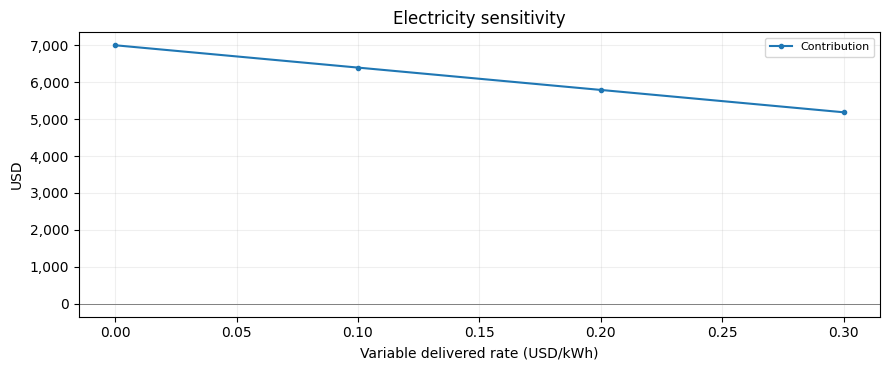

In [5]:
tariffs = (0.0, 0.10, 0.20, 0.30)
contributions = [
    foundation_revenue_usd
    - non_power_cost_usd
    - electricity_cost_usd(
        **(power_inputs | {"delivered_usd_per_kwh": rate})
    ).total_bill_usd
    for rate in tariffs
]
display(
    plot_finance_series(
        {"Contribution": contributions},
        title="Electricity sensitivity",
        xlabel="Variable delivered rate (USD/kWh)",
        x_values=tariffs,
    )
)


def power_explorer(
    values,
    baseline=power_inputs.copy(),
    revenue=foundation_revenue_usd,
    cost=non_power_cost_usd,
):
    from liquid_compute.power import electricity_cost_usd

    rates = (0.10, values["Selected USD/kWh"], 0.20)
    amounts = [
        revenue
        - cost
        - electricity_cost_usd(
            **(
                baseline
                | {"it_kw_per_gpu": values["IT kW/GPU"], "delivered_usd_per_kwh": rate}
            )
        ).total_bill_usd
        for rate in rates
    ]
    return {"Contribution": amounts}


explore_finance_series(
    {"IT kW/GPU": 0.7, "Selected USD/kWh": 0.10},
    power_explorer,
    title="Power and delivered-rate comparison",
    xlabel="Rate case",
    bar=True,
    x_tick_labels=("0.10 USD/kWh", "Selected rate", "0.20 USD/kWh"),
);

## Experiment 1 · Double the variable rate

Change USD 0.10/kWh to USD 0.20/kWh without changing energy usage or the fixed service charge. Only the energy-dependent component doubles. The total bill does not double because the USD 200 fixed charge remains unchanged.

Keeping billing inputs fixed makes the business effect traceable to this one price change. It does not assume the operator can pass the increase to customers; a pass-through would need an explicit commercial term and a separate revenue calculation.

In [6]:
high_bill = electricity_cost_usd(**(power_inputs | {"delivered_usd_per_kwh": 0.20}))
high_contribution = (
    foundation_revenue_usd - non_power_cost_usd - high_bill.total_bill_usd
)
show_finance_table(
    ["Rate USD/kWh", "Variable USD", "Fixed USD", "Total bill USD", "Contribution USD"],
    [
        [
            0.10,
            bill.energy_cost_usd,
            bill.fixed_charge_usd,
            bill.total_bill_usd,
            base_contribution,
        ],
        [
            0.20,
            high_bill.energy_cost_usd,
            high_bill.fixed_charge_usd,
            high_bill.total_bill_usd,
            high_contribution,
        ],
    ],
)

| Rate USD/kWh | Variable USD | Fixed USD | Total bill USD | Contribution USD |
| --- | --- | --- | --- | --- |
| 0.10 | 604.80 | 200.00 | 804.80 | 6,395.20 |
| 0.20 | 1,209.60 | 200.00 | 1,409.60 | 5,790.40 |

The new bill is USD 1,409.60 and contribution falls to USD 5,790.40, a USD 604.80 decline. That is exactly the additional variable charge.

## Experiment 2 · Change technical load independently

Assume idle draw of 0.2 kW/GPU and active draw of 0.7. Interpolate average draw as idle + technical active fraction × (active−idle). A 50% technical active fraction therefore gives 0.45 kW/GPU.

Billed utilization remains 75% and revenue remains USD 21,600 in every row. Technical activity might differ because of workload behavior or idle periods; this illustrative interpolation does not infer a real workload's power curve.

In [7]:
load_cases = []
for active_fraction in (0.0, 0.5, 1.0):
    draw = average_it_kw_per_gpu(
        idle_kw_per_gpu=0.2,
        active_kw_per_gpu=0.7,
        technical_active_fraction=active_fraction,
    )
    load_bill = electricity_cost_usd(**(power_inputs | {"it_kw_per_gpu": draw}))
    load_cases.append(
        [
            active_fraction,
            draw,
            foundation_revenue_usd,
            load_bill.total_bill_usd,
            foundation_revenue_usd - non_power_cost_usd - load_bill.total_bill_usd,
        ]
    )
show_finance_table(
    [
        "Technical active fraction",
        "Average kW/GPU",
        "Unchanged revenue USD",
        "Bill USD",
        "Contribution USD",
    ],
    load_cases,
)

| Technical active fraction | Average kW/GPU | Unchanged revenue USD | Bill USD | Contribution USD |
| --- | --- | --- | --- | --- |
| 0.00 | 0.20 | 21,600.00 | 372.80 | 6,827.20 |
| 0.50 | 0.45 | 21,600.00 | 588.80 | 6,611.20 |
| 1.00 | 0.70 | 21,600.00 | 804.80 | 6,395.20 |

At 50% technical activity, average draw is 0.45 kW/GPU, the bill is USD 588.80, and contribution is USD 6,611.20. Reduced technical draw lowers electricity cost without mechanically lowering billed revenue in this declared scenario.

## Experiment 3 · Compare an energy component with the full bill

A synthetic wholesale energy component of USD 0.06/kWh gives 6,048 × 0.06 = USD 362.88. That is not the delivered bill. [EIA explains](https://www.eia.gov/tools/faqs/faq.php?id=507&t=5) that its average retail prices include generation, transmission, distribution, taxes and fees, and are not individual utility rates.

Our invented variable delivered rate and separately charged service fee define this example's bill; neither is an EIA tariff or observed quote.

In [8]:
energy_component_usd = bill.facility_energy_kwh * 0.06
show_finance_table(
    ["Charge comparison", "USD"],
    [
        ["Synthetic energy-only component", energy_component_usd],
        ["Assumed variable delivered charge", bill.energy_cost_usd],
        ["Separately charged service fee", bill.fixed_charge_usd],
        ["Total assumed bill", bill.total_bill_usd],
    ],
)

| Charge comparison | USD |
| --- | --- |
| Synthetic energy-only component | 362.88 |
| Assumed variable delivered charge | 604.80 |
| Separately charged service fee | 200.00 |
| Total assumed bill | 804.80 |

The energy-only figure understates the assumed total bill by USD 441.92. This difference is specific to the stated hypothetical inputs; it is not an estimate of any actual utility's delivery markup.

## Assign the cost before assessing exposure

The operator's cost sensitivity matters because it pays the electricity bill. A reseller buying all-in capacity has a different direct exposure unless its contract passes power charges through. Compare the already calculated cases, then identify which party and contract would actually bear each change.

In [9]:
show_finance_table(
    ["Previously calculated case", "Contribution USD"],
    [
        ["Base", base_contribution],
        ["Higher electricity price", high_contribution],
        ["50% technical activity", load_cases[1][-1]],
    ],
)

| Previously calculated case | Contribution USD |
| --- | --- |
| Base | 6,395.20 |
| Higher electricity price | 5,790.40 |
| 50% technical activity | 6,611.20 |

**Next:** E4 optionally examines floating-rate financing; E6 separately examines cost per useful output. These extensions may enter the planned capstone only when relevant to its chosen structure.

The constant facility multiplier, linear technical-load interpolation and flat variable rate simplify operations. Demand charges, nonlinear tariffs, time-of-use pricing, taxes outside the stated rate, hardware capital cost and financing remain excluded. No power hedge or claim about actual GPU specifications has been introduced.